### Setup and Reload Cleaned Data
This notebook performs exploratory data analysis on the cleaned outputs from 02_data_cleaning.ipynb. All datasets are reloaded from 05_processed/ so this notebook can run independently.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os

BASE = "/Users/alexia/Documents/CASA/Dissertation"

# Reload cleaned datasets produced by 02_data_cleaning.ipynb
census_london = pd.read_csv(os.path.join(BASE, "05_processed/census_london_clean.csv"))
imd_london    = pd.read_csv(os.path.join(BASE, "05_processed/imd_london_clean.csv"))
osev_london   = pd.read_csv(os.path.join(BASE, "05_processed/osev_london_clean.csv"))
zapmap_clean  = pd.read_csv(os.path.join(BASE, "05_processed/zapmap_clean.csv"), parse_dates=["charging_start"])

figures_dir = os.path.join(BASE, "06_outputs/figures")
os.makedirs(figures_dir, exist_ok=True)

print("Datasets reloaded.")
print(f"census_london: {census_london.shape}, imd_london: {imd_london.shape}, "
      f"osev_london: {osev_london.shape}, zapmap_clean: {zapmap_clean.shape}")

Datasets reloaded.
census_london: (4994, 4), imd_london: (4994, 10), osev_london: (23015, 11), zapmap_clean: (215037, 20)


## Block A — Income Deprivation Distribution

This block joins the income domain score (IoD2025 File 7) to LSOA 2021 boundary geometries and produces a choropleth map of income deprivation across Greater London. This map establishes the spatial baseline for the equity argument developed in later notebooks: LSOAs with higher income deprivation scores are the ones that receive the largest demand uplift under the (1 + α·IMDᵢ) equity weighting in Phase 1.

### peek boundary file

In [2]:
# Load LSOA 2021 boundary geometries (ONS Open Geography, Generalised Clipped V5)
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))

print("Shape:", lsoa_boundaries.shape)
print("Columns:", lsoa_boundaries.columns.tolist())
print("CRS:", lsoa_boundaries.crs)
lsoa_boundaries.head(3)

Shape: (35672, 9)
Columns: ['LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'GlobalID', 'geometry']
CRS: EPSG:27700


,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E01000001,City of London 001A,NaN,532123,181632,51.5182,-0.09715,86214465-5cf4-4e8f-9492-3667471c42d6,"POLYGON ((532105.312 182010.574, 532162.491 18..."
1,E01000002,City of London 001B,NaN,532480,181715,51.5188,-0.09197,cd40c491-6567-405f-8c18-426e17b356ce,"POLYGON ((532634.497 181926.016, 532619.141 18..."
2,E01000003,City of London 001C,NaN,532239,182033,51.5217,-0.09533,7fd27aaf-d858-4e46-9099-92b43f66b948,"POLYGON ((532135.138 182198.131, 532158.25 182..."


### reproject, filter to London, merge income score

In [3]:
# Reproject to EPSG:27700 (British National Grid) — standard for all spatial operations
# in this dissertation, consistent with candidate site generation in later notebooks
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

# Restrict to the 4,994 Greater London LSOAs already confirmed in census_london
# NOTE: assumes the boundary file's LSOA code column is named 'LSOA21CD' (ONS standard).
# Check the printed column list above and adjust this name if it differs.
london_codes = set(census_london["lsoa_code"])
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_codes)].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})

print(f"LSOA boundaries matched: {len(lsoa_london)} / {len(london_codes)} expected")

# Merge income score onto boundary geometries
income_map = lsoa_london[["lsoa_code", "geometry"]].merge(
    imd_london[["lsoa_code", "income_score", "income_decile"]],
    on="lsoa_code", how="left"
)
print("Missing income_score after merge:", income_map["income_score"].isna().sum())

LSOA boundaries matched: 4994 / 4994 expected
Missing income_score after merge: 0


### Fig A1 — income score choropleth

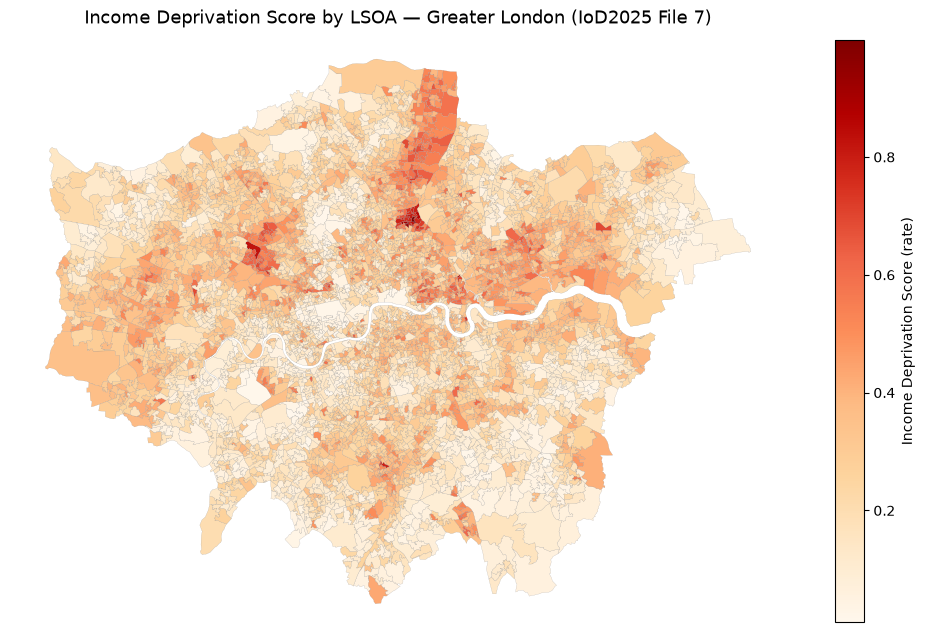

Saved: fig_income_score_map.png


In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
income_map.plot(
    column="income_score", cmap="OrRd", linewidth=0.1,
    edgecolor="grey", legend=True, ax=ax,
    legend_kwds={"label": "Income Deprivation Score (rate)", "shrink": 0.6}
)
ax.set_title("Income Deprivation Score by LSOA — Greater London (IoD2025 File 7)", fontsize=13)
ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_income_score_map.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_income_score_map.png")

## Block B — Utilisation-Adjusted Supply Baseline (Sᵢᵉᶠᶠ)

This block computes the time-based utilisation rate urⱼ for every EVSE active in the GLA/Zapmap session data (following the definition formalised by Borlaug et al. 2023), spatially joins EVSE locations to LSOAs, and aggregates residual effective capacity Sᵢᵉᶠᶠ = Σ(1 − urⱼ) at LSOA level. It also explores two secondary questions: the shape of the session duration distribution (top-up vs overnight charging behaviour), and whether EVSEs co-located at the same physical site show different utilisation levels ('hot vs cold' chargers).

### compute ur_j

In [5]:
# Step 1: aggregate total charging duration per EVSE across the 7-day observation window
evse_duration = zapmap_clean.groupby("evse_id")["charging_duration"].sum().reset_index()
evse_duration.columns = ["evse_id", "total_duration_min"]

# Step 2: time-based utilisation rate ur_j = total duration / 10,080 min (7 days), clipped to [0, 1]
# Clipping handles edge cases from overlapping/concurrent session records at the same EVSE
evse_duration["ur_j"] = (evse_duration["total_duration_min"] / 10080).clip(upper=1.0)

print("ur_j stats:")
print(evse_duration["ur_j"].describe())
print()
print(f"EVSEs with ur_j == 1.0 (fully saturated): {(evse_duration['ur_j'] == 1.0).sum()}")

ur_j stats:
count    10465.000000
mean         0.411883
std          0.418686
min          0.000099
25%          0.000298
50%          0.342460
75%          0.988988
max          1.000000
Name: ur_j, dtype: float64

EVSEs with ur_j == 1.0 (fully saturated): 2596


### attach coordinates

In [6]:
# Step 3: attach coordinates — each EVSE inherits its location_id's lat/lon (constant within a location)
evse_coords = zapmap_clean.groupby("evse_id").agg(
    location_id=("location_id", "first"),
    latitude=("latitude", "first"),
    longitude=("longitude", "first"),
).reset_index()

evse_panel = evse_duration.merge(evse_coords, on="evse_id", how="left")
print("EVSE panel shape:", evse_panel.shape)
print("Missing coordinates:", evse_panel[["latitude", "longitude"]].isna().any(axis=1).sum())

EVSE panel shape: (10465, 6)
Missing coordinates: 0


### spatial join EVSE → LSOA

In [7]:
# Step 4: spatial join EVSE point locations to LSOA polygons
# Coordinates are WGS84 (EPSG:4326) — build GeoDataFrame then reproject to EPSG:27700
evse_gdf = gpd.GeoDataFrame(
    evse_panel,
    geometry=gpd.points_from_xy(evse_panel["longitude"], evse_panel["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=27700)

evse_joined = gpd.sjoin(
    evse_gdf, lsoa_london[["lsoa_code", "geometry"]],
    how="left", predicate="within"
).drop(columns=["index_right"])

matched = evse_joined["lsoa_code"].notna().sum()
print(f"EVSEs matched to a London LSOA: {matched} / {len(evse_joined)}")

EVSEs matched to a London LSOA: 10465 / 10465


### aggregate Sᵢᵉᶠᶠ and save

In [8]:
# Step 5: residual capacity per EVSE, aggregated to LSOA level
evse_joined["residual_j"] = 1 - evse_joined["ur_j"]

seff_by_lsoa = evse_joined.dropna(subset=["lsoa_code"]).groupby("lsoa_code")["residual_j"].sum().reset_index()
seff_by_lsoa.columns = ["lsoa_code", "seff"]

# Merge onto the full 4,994 London LSOA list — LSOAs with no observed EVSE get Sᵢᵉᶠᶠ = 0
seff_london = census_london[["lsoa_code", "lsoa_name"]].merge(seff_by_lsoa, on="lsoa_code", how="left")
seff_london["seff"] = seff_london["seff"].fillna(0)

print("=== Sᵢᵉᶠᶠ Summary ===")
print(seff_london["seff"].describe())
print(f"\nLSOAs with seff == 0 (no EVSE observed): {(seff_london['seff'] == 0).sum()}")

output_path = os.path.join(BASE, "05_processed/seff_london.csv")
seff_london.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

=== Sᵢᵉᶠᶠ Summary ===
count    4994.000000
mean        1.232409
std         2.106752
min         0.000000
25%         0.000000
50%         0.000000
75%         1.791121
max        22.898611
Name: seff, dtype: float64

LSOAs with seff == 0 (no EVSE observed): 2675

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/seff_london.csv


### Fig B1 — ur_j distribution

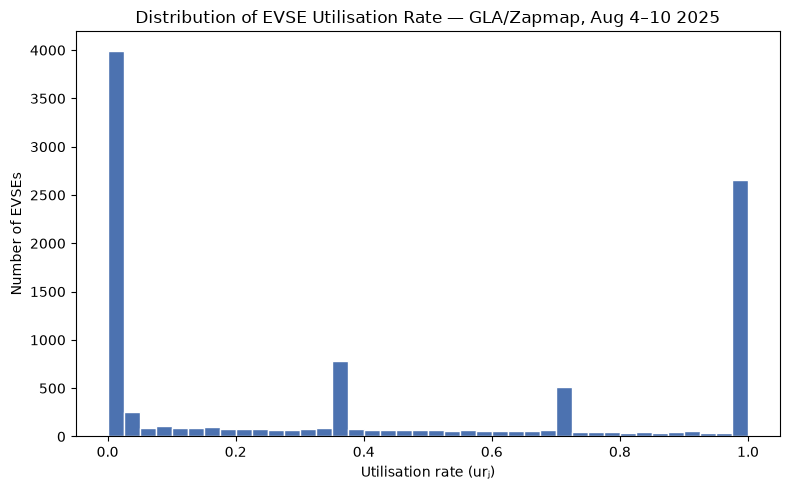

Saved: fig_ur_distribution.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(evse_duration["ur_j"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Utilisation rate (urⱼ)")
ax.set_ylabel("Number of EVSEs")
ax.set_title("Distribution of EVSE Utilisation Rate — GLA/Zapmap, Aug 4–10 2025")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_ur_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_ur_distribution.png")

### Fig B2 — Sᵢᵉᶠᶠ choropleth

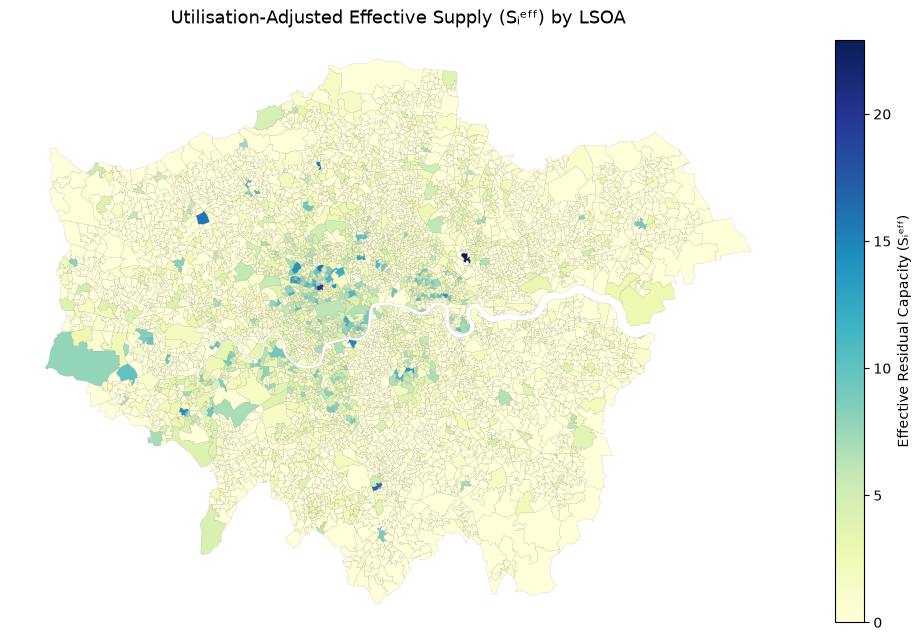

Saved: fig_seff_map.png


In [10]:
seff_map = lsoa_london[["lsoa_code", "geometry"]].merge(seff_london, on="lsoa_code", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
seff_map.plot(
    column="seff", cmap="YlGnBu", linewidth=0.1,
    edgecolor="grey", legend=True, ax=ax,
    legend_kwds={"label": "Effective Residual Capacity (Sᵢᵉᶠᶠ)", "shrink": 0.6}
)
ax.set_title("Utilisation-Adjusted Effective Supply (Sᵢᵉᶠᶠ) by LSOA", fontsize=13)
ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_seff_map.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_seff_map.png")

### Fig B3 — session duration distribution

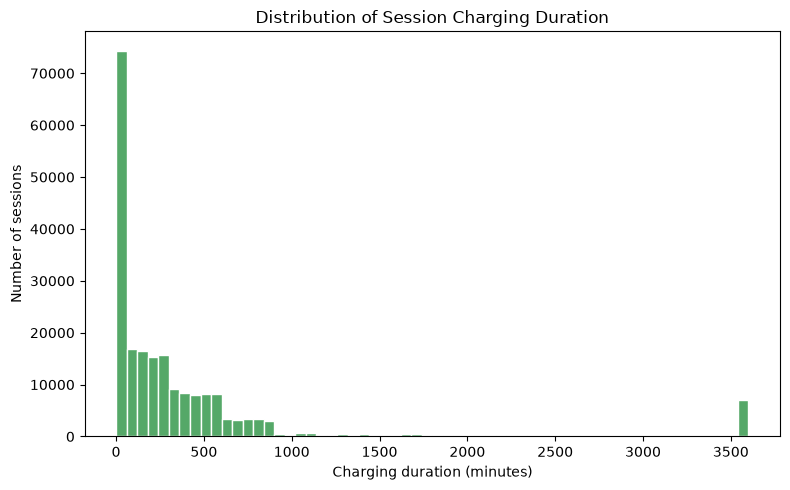

Saved: fig_duration_distribution.png


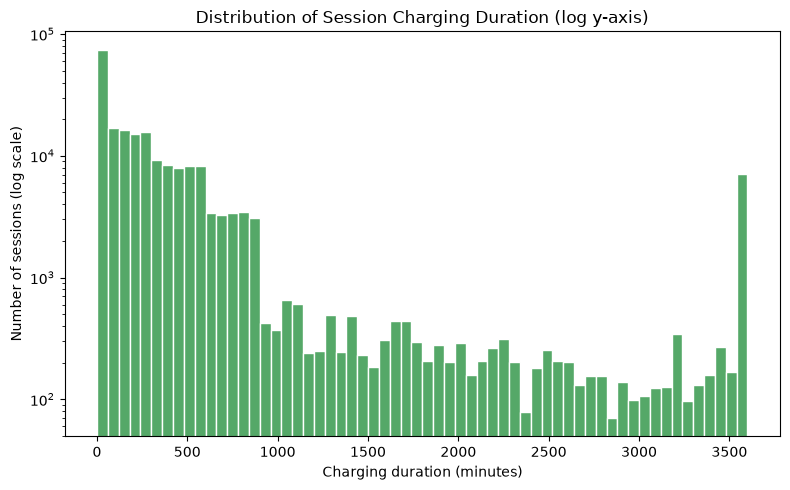

Saved: fig_duration_distribution_log.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(zapmap_clean["charging_duration"], bins=60, color="#55A868", edgecolor="white")
ax.set_xlabel("Charging duration (minutes)")
ax.set_ylabel("Number of sessions")
ax.set_title("Distribution of Session Charging Duration")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_duration_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_duration_distribution.png")

# Log y-axis version — makes bimodality (short top-up vs long overnight sessions) easier to see
# when the bulk of sessions are short and a long tail dominates a linear-scale plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(zapmap_clean["charging_duration"], bins=60, color="#55A868", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Charging duration (minutes)")
ax.set_ylabel("Number of sessions (log scale)")
ax.set_title("Distribution of Session Charging Duration (log y-axis)")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_duration_distribution_log.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_duration_distribution_log.png")

### Fig B4 — location-level utilisation variance

Locations with >1 EVSE: 1527
count    1527.000000
mean        0.176603
std         0.174801
min         0.000000
25%         0.012767
50%         0.121550
75%         0.308310
max         0.700653
Name: std, dtype: float64


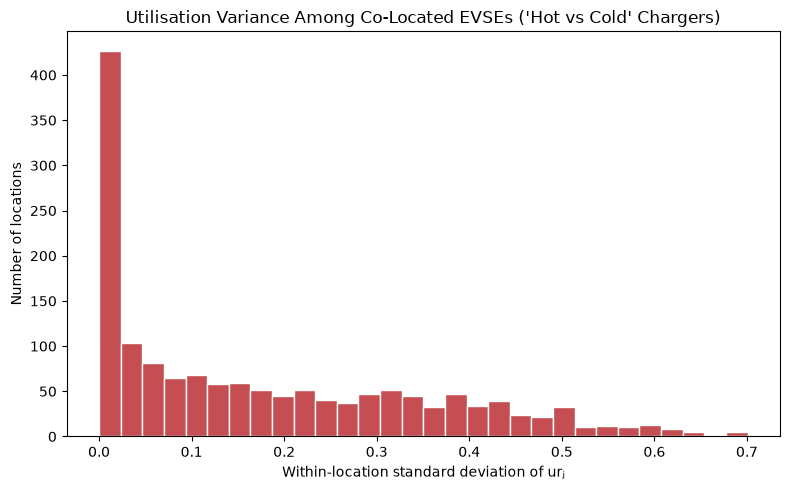

Saved: fig_location_level_variance.png


In [12]:
# Step 6: do co-located EVSEs (same location_id) show different utilisation levels?
evse_per_location = evse_joined.groupby("location_id")["ur_j"].agg(["count", "std", "mean"]).reset_index()
multi_evse_locations = evse_per_location[evse_per_location["count"] > 1].dropna(subset=["std"])

print(f"Locations with >1 EVSE: {len(multi_evse_locations)}")
print(multi_evse_locations["std"].describe())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(multi_evse_locations["std"], bins=30, color="#C44E52", edgecolor="white")
ax.set_xlabel("Within-location standard deviation of urⱼ")
ax.set_ylabel("Number of locations")
ax.set_title("Utilisation Variance Among Co-Located EVSEs ('Hot vs Cold' Chargers)")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_location_level_variance.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_location_level_variance.png")

### update pipeline_summary.csv

In [13]:
# Fill in the "EVSEs matched to LSOA via spatial join" row that was left pending in 02_data_cleaning
pipeline_summary = pd.read_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"))
pipeline_summary.loc[
    pipeline_summary["Item"] == "EVSEs matched to LSOA via spatial join", "Count"
] = matched

pipeline_summary.to_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"), index=False)
print(pipeline_summary.to_string(index=False))

TypeError: Invalid value '10465' for dtype 'str'. Value should be a string or missing value, got 'int64' instead.